In [1]:
import time
import torch
import tensorflow as tf
import psutil

class PowerMonitor:
    def __init__(self):
        self.gpu_available = tf.config.list_physical_devices('GPU')
        
        # Hardware power specifications (adjust these values for your system)
        self.cpu_tdp = 65    # Typical TDP for desktop CPUs in watts
        self.gpu_tdp = 250   # Typical TDP for desktop GPUs in watts
        
    def get_stats(self):
        """Get system stats with power estimation"""
        stats = {
            'timestamp': time.time(),
            'cpu_%': psutil.cpu_percent(interval=0.1),
            'ram_mb': psutil.virtual_memory().used / (1024**2),
            'gpu_mem_mb': 0,
            'power_w': self.cpu_tdp * (psutil.cpu_percent()/100) * 0.85  # Base CPU power
        }
        
        if self.gpu_available:
            try:
                # TensorFlow GPU memory monitoring
                mem_info = tf.config.experimental.get_memory_info('GPU:0')
                stats.update({
                    'gpu_mem_mb': mem_info['current'] / (1024**2),
                    'power_w': self.cpu_tdp * (psutil.cpu_percent()/100) * 0.85 + 
                              self.gpu_tdp * 0.5 * 0.75  # Add GPU power estimate
                })
            except:
                pass
                
        return stats

# Initialize monitor
monitor = PowerMonitor()

c:\Users\aneek\anaconda3\envs\tf_gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers


def build_inceptionv3_model(input_shape=(160, 160, 3)):
    # ImageNet-pretrained InceptionV3 backbone
    base_model = tf.keras.applications.InceptionV3(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Enable full fine-tuning
    base_model.trainable = True

    inputs = layers.Input(
        shape=input_shape,
        dtype=tf.uint8,
        name="input_images"
    )

    # Images were loaded by OpenCV in BGR format.
    # Convert BGR -> RGB and uint8 -> float32.
    x = layers.Lambda(
        lambda image: tf.reverse(
            tf.cast(image, tf.float32),
            axis=[-1]
        ),
        name="bgr_to_rgb"
    )(inputs)

    # InceptionV3 preprocessing:
    # pixel values [0, 255] -> [-1, 1]
    x = layers.Lambda(
        lambda image:
        tf.keras.applications.inception_v3.preprocess_input(
            image
        ),
        name="inceptionv3_preprocessing"
    )(x)

    # Full backbone fine-tuning while keeping BatchNorm
    # moving statistics fixed
    x = base_model(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="dense_256"
    )(x)

    x = layers.Dropout(
        0.5,
        name="dropout"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="prediction"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="InceptionV3_Deepfake_Detector"
    )

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc",
                curve="ROC"
            ),
            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model, base_model


model, base_model = build_inceptionv3_model(
    input_shape=(160, 160, 3)
)

model.summary()

print("\nBackbone trainable:", base_model.trainable)

print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(variable)
        for variable in model.trainable_weights
    )
)

Model: "InceptionV3_Deepfake_Detector"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_images (InputLayer)   [(None, 160, 160, 3)]     0         
                                                                 
 bgr_to_rgb (Lambda)         (None, 160, 160, 3)       0         
                                                                 
 inceptionv3_preprocessing (  (None, 160, 160, 3)      0         
 Lambda)                                                         
                                                                 
 inception_v3 (Functional)   (None, 3, 3, 2048)        21802784  
                                                                 
 global_average_pooling (Glo  (None, 2048)             0         
 balAveragePooling2D)                                            
                                                                 
 dense_256 (Dense)           (None, 2

# Wild deepfake

In [13]:
import h5py
import numpy as np

H5_PATH = (
    r"D:\thesis\dataset\WildDeepfake\leakage_free_subset"
    r"\wilddeepfake_sequence_disjoint_face_preprocessed.h5"
)

with h5py.File(H5_PATH, "r") as h5f:
    # Load image arrays
    train_images = h5f["train_images"][:]
    train_labels = h5f["train_labels"][:]

    val_images = h5f["val_images"][:]
    val_labels = h5f["val_labels"][:]

    test_images = h5f["test_images"][:]
    test_labels = h5f["test_labels"][:]

# Verify dataset sizes
print(f"Total train: {len(train_images)} images")
print(f"Total validation: {len(val_images)} images")
print(f"Total test: {len(test_images)} images")

print(f"Train labels: {len(train_labels)}")
print(f"Validation labels: {len(val_labels)}")
print(f"Test labels: {len(test_labels)}")

# Verify shapes and data types
print("\nArray information:")
print(f"Train images: {train_images.shape}, dtype={train_images.dtype}")
print(f"Validation images: {val_images.shape}, dtype={val_images.dtype}")
print(f"Test images: {test_images.shape}, dtype={test_images.dtype}")

print(f"Train labels: {train_labels.shape}, dtype={train_labels.dtype}")
print(f"Validation labels: {val_labels.shape}, dtype={val_labels.dtype}")
print(f"Test labels: {test_labels.shape}, dtype={test_labels.dtype}")

# Verify class distributions
print("\nClass distribution:")
print(
    f"Train: Real={np.sum(train_labels == 0)}, "
    f"Fake={np.sum(train_labels == 1)}"
)
print(
    f"Validation: Real={np.sum(val_labels == 0)}, "
    f"Fake={np.sum(val_labels == 1)}"
)
print(
    f"Test: Real={np.sum(test_labels == 0)}, "
    f"Fake={np.sum(test_labels == 1)}"
)

Total train: 36000 images
Total validation: 6000 images
Total test: 18000 images
Train labels: 36000
Validation labels: 6000
Test labels: 18000

Array information:
Train images: (36000, 160, 160, 3), dtype=uint8
Validation images: (6000, 160, 160, 3), dtype=uint8
Test images: (18000, 160, 160, 3), dtype=uint8
Train labels: (36000,), dtype=uint8
Validation labels: (6000,), dtype=uint8
Test labels: (18000,), dtype=uint8

Class distribution:
Train: Real=9000, Fake=27000
Validation: Real=1500, Fake=4500
Test: Real=4500, Fake=13500


In [4]:

# Train model
history = model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
2250/2250 [==============================] - 161s 67ms/step - loss: 0.3424 - accuracy: 0.8518 - precision: 0.8654 - recall: 0.9501 - roc_auc: 0.8913 - pr_auc: 0.9583 - val_loss: 0.2176 - val_accuracy: 0.9125 - val_precision: 0.9222 - val_recall: 0.9647 - val_roc_auc: 0.9611 - val_pr_auc: 0.9857
Epoch 2/10
2250/2250 [==============================] - 137s 61ms/step - loss: 0.1355 - accuracy: 0.9503 - precision: 0.9620 - recall: 0.9721 - roc_auc: 0.9832 - pr_auc: 0.9934 - val_loss: 0.2245 - val_accuracy: 0.9278 - val_precision: 0.9506 - val_recall: 0.9533 - val_roc_auc: 0.9666 - val_pr_auc: 0.9845
Epoch 3/10
2250/2250 [==============================] - 138s 61ms/step - loss: 0.0894 - accuracy: 0.9688 - precision: 0.9769 - recall: 0.9817 - roc_auc: 0.9922 - pr_auc: 0.9968 - val_loss: 0.3743 - val_accuracy: 0.8825 - val_precision: 0.9679 - val_recall: 0.8722 - val_roc_auc: 0.9573 - val_pr_auc: 0.9856
Epoch 4/10
2250/2250 [==============================] - 140s 62ms/step - loss: 

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [ ]:
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 22s 19ms/step - loss: 0.9316 - accuracy: 0.7596 - precision: 0.8398 - recall: 0.8397 - roc_auc: 0.6795 - pr_auc: 0.8398

Test results:
loss: 0.9316
accuracy: 0.7596
precision: 0.8398
recall: 0.8097
roc_auc: 0.6759
pr_auc: 0.8398



In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 13.0%
RAM Used: 1103.6 MB
Time Usage: 25.0 s
GPU Memory Used: 4667.3 MB
Power Consumption: 93W


save the model

In [8]:
import tensorflow as tf

# After training the model
model.save('Inception_V3_160_wild.h5')  # Saves the entire model to a file

In [9]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Inception_V3_wilddeepfake_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
D:\thesis\results\Inception_V3_wilddeepfake_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


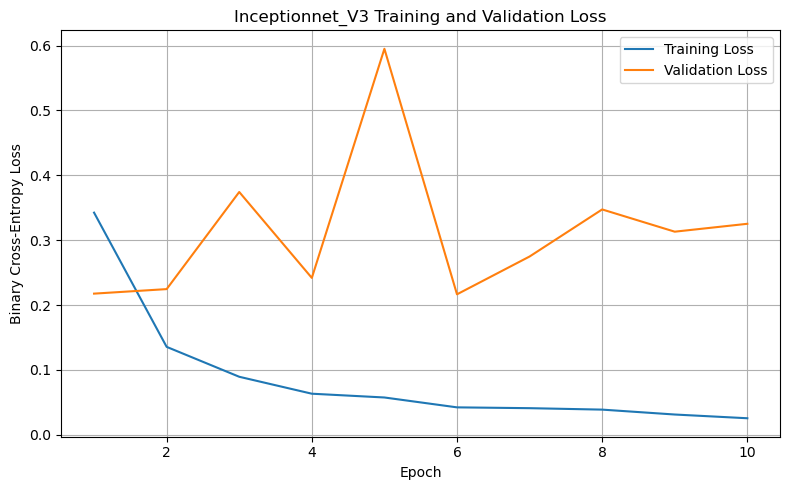

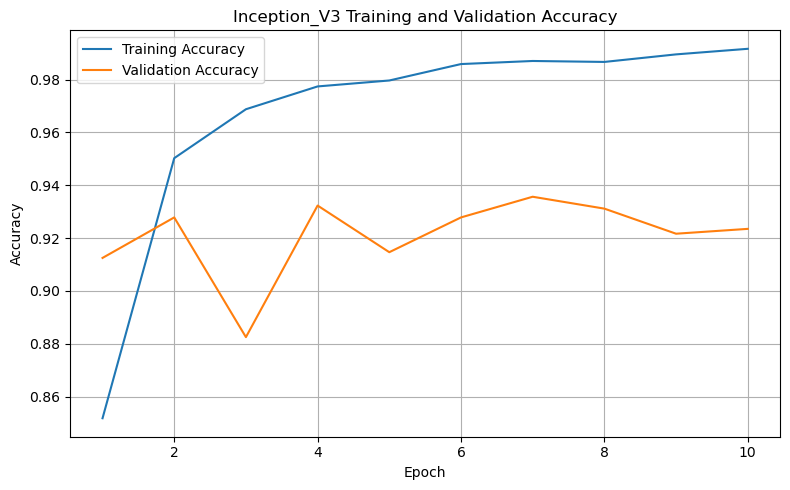

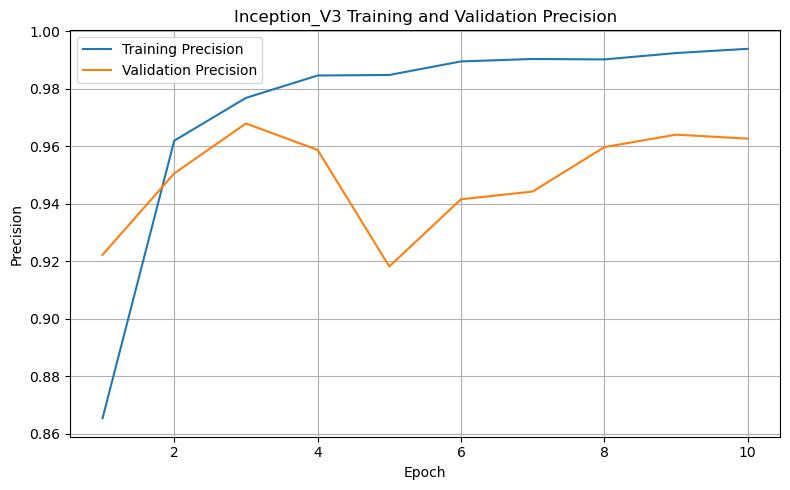

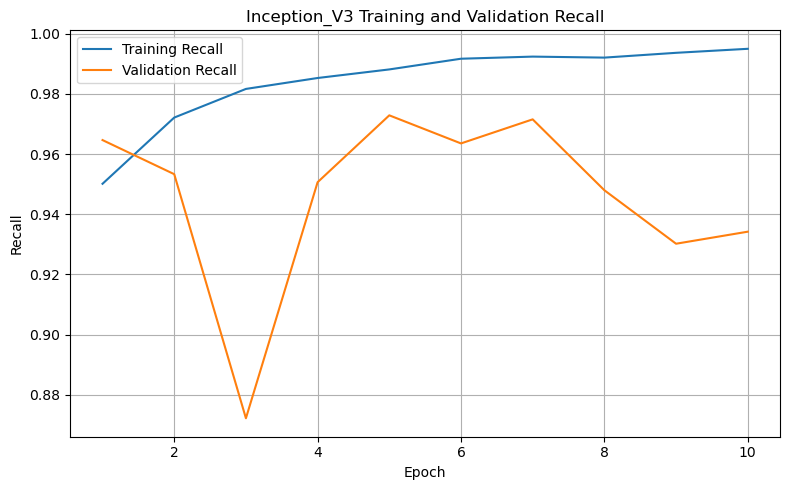

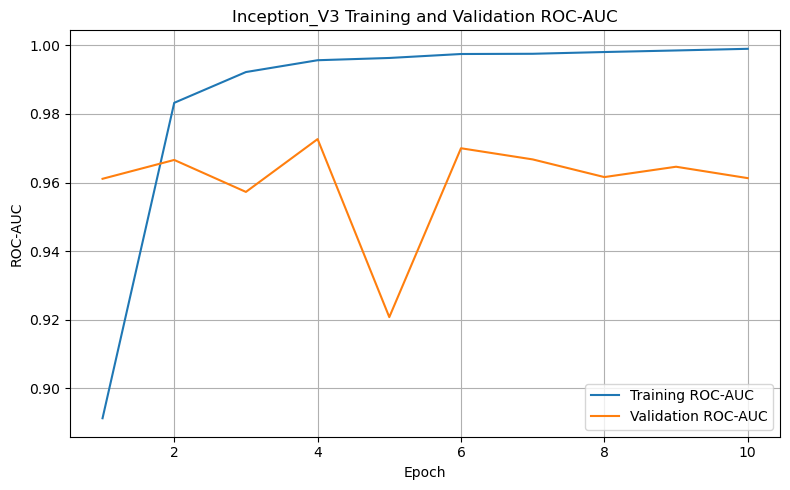

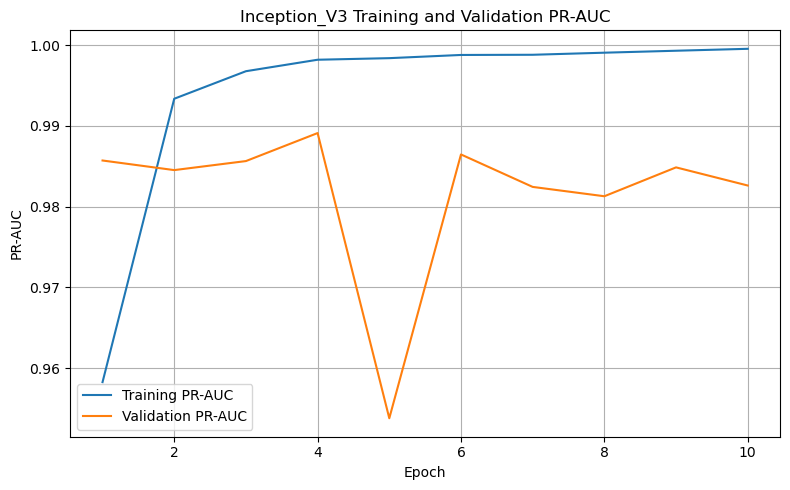

In [13]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Inceptionnet_V3 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Inception_V3 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Inception_V3 Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Inception_V3 Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Inception_V3 Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Inception_V3 Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Inception_V3_wilddeepfake_10epochs.h5")

H5_PATH = (
    r"D:\thesis\dataset\WildDeepfake\leakage_free_subset"
    r"\wilddeepfake_sequence_disjoint_face_preprocessed.h5"
)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

# Load only the test split
with h5py.File(H5_PATH, "r") as h5f:
    test_images = h5f["test_images"][:]
    test_labels = h5f["test_labels"][:]

print("Model loaded")
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Model loaded
Test images: (18000, 160, 160, 3)
Test labels: (18000,)


In [10]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_images),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_images[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_images,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_images)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_3180\2159758100.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 21.39 seconds, 1.1885 ms/image

Starting resource run 2/5
Run 2: 20.28 seconds, 1.1266 ms/image

Starting resource run 3/5
Run 3: 20.69 seconds, 1.1495 ms/image

Starting resource run 4/5
Run 4: 20.74 seconds, 1.1521 ms/image

Starting resource run 5/5
Run 5: 20.27 seconds, 1.1262 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,21.393392,1.188522,841.381305,3.219555,4.928125,7157.296875,8493.275250,8515.613281,1335.978375,1358.316406,...,7000.558594,7000.558594,0.0,0.0,86.721649,100,61.646222,82.232,0.362659,1
1,20.278618,1.126590,887.634458,3.257354,4.928125,7157.492188,8495.293351,8515.988281,1337.801163,1358.496094,...,7000.558594,7000.558594,0.0,0.0,89.282609,100,64.518560,84.685,0.360134,2
2,20.691842,1.149547,869.908045,3.235439,4.928125,7158.730469,8496.001891,8516.570312,1337.271422,1357.839844,...,7000.558594,7000.558594,0.0,0.0,87.984043,100,62.763739,73.901,0.358629,3
3,20.738076,1.152115,867.968679,3.208993,4.881250,7158.789062,8495.168862,8516.753906,1336.379800,1357.964844,...,7000.558594,7000.558594,0.0,0.0,87.712766,100,63.050957,96.824,0.361487,4
4,20.271916,1.126218,887.927923,3.219843,4.928125,7158.828125,8495.793374,8516.066406,1336.965249,1357.238281,...,7000.558594,7000.558594,0.0,0.0,89.240437,100,65.551038,82.946,0.366983,5


In [11]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Inception_V3 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Inception_V3 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,20.674769,0.458242,20.105785,21.243752
1,latency_ms_per_image,1.148598,0.025458,1.116988,1.180208
2,throughput_images_per_s,870.964082,19.045351,847.316155,894.612009
3,average_cpu_percent,3.228237,0.018814,3.204876,3.251597
4,peak_cpu_percent,4.918750,0.020963,4.892721,4.944779
5,average_ram_mb,8495.106546,1.080023,8493.765520,8496.447572
6,peak_ram_mb,8516.198437,0.461206,8515.625775,8516.771100
7,average_incremental_ram_mb,1336.879202,0.719748,1335.985517,1337.772886
8,peak_incremental_ram_mb,1357.971094,0.487120,1357.366254,1358.575934
9,average_gpu_memory_mb,7000.558594,0.000000,7000.558594,7000.558594



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 1.149 ± 0.025 (95% CI: 1.117–1.180)
peak_ram_mb: 8516.198 ± 0.461 (95% CI: 8515.626–8516.771)
peak_gpu_memory_mb: 7000.559 ± 0.000 (95% CI: 7000.559–7000.559)
average_gpu_utilization_percent: 88.188 ± 1.087 (95% CI: 86.839–89.538)
average_gpu_power_w: 63.506 ± 1.535 (95% CI: 61.600–65.412)


In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_images,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_images,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Inception_V3 — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")


print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)

1125/1125 [==============================] - 19s 17ms/step

Inception_V3 — COMPLETE TEST-SET EVALUATION
Number of test samples:     18000
Decision threshold:         0.5000
Test loss:                  0.931579

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.759454
Precision:                  0.839819
Recall/Sensitivity:         0.839778
F1-score:                   0.839737
ROC-AUC:                    0.679527
PR-AUC:                     0.839875
Average Precision:          0.839855
EER:                        0.320563
EER threshold:              0.659566

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.679511
Specificity:                0.519544
Matthews correlation:       0.359006

Confusion matrix
----------------------------------------------------------------------
Rows = actual classes; columns = predicted classes
Class or

genralization

In [15]:
#celeb on wilddeepfake
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on Celeb-DF(V2) (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 9s 21ms/step - loss: 1.3492 - accuracy: 0.6148 - precision: 0.9489 - recall: 0.6067 - roc_auc: 0.7085 - pr_auc: 0.9552

Test results of wild deepfake dataset on Celeb-DF(V2) (Inception_V3):
loss: 1.3492
accuracy: 0.6148
precision: 0.9489
recall: 0.6067
roc_auc: 0.7085
pr_auc: 0.9552


In [17]:
#dfc on wilddeepfake

test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on DFC (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

188/188 [==============================] - 8s 36ms/step - loss: 1.6777 - accuracy: 0.5030 - precision: 0.5034 - recall: 0.4493 - roc_auc: 0.5047 - pr_auc: 0.5015

Test results of wild deepfake dataset on DFC (Inception_V3):
loss: 1.6777
accuracy: 0.5030
precision: 0.5034
recall: 0.4493
roc_auc: 0.5047
pr_auc: 0.5015


In [19]:
#ff++ on wilddeepfake

test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on FF++ (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

155/155 [==============================] - 3s 22ms/step - loss: 1.7826 - accuracy: 0.5846 - precision: 0.5033 - recall: 0.2231 - roc_auc: 0.5476 - pr_auc: 0.4964

Test results of wild deepfake dataset on FF++ (Inception_V3):
loss: 1.7826
accuracy: 0.5846
precision: 0.5033
recall: 0.2231
roc_auc: 0.5476
pr_auc: 0.4964


# Celeb

In [15]:
import os
import cv2
import numpy as np

SAVE_ROOT = r'D:\thesis\celeb_processed'

def load_split(split_name, class_name):
    """Reload saved frames, grouped by video."""
    base = os.path.join(SAVE_ROOT, split_name, class_name)
    nested, ids = [], []
    for vid_id in sorted(os.listdir(base)):
        vid_dir = os.path.join(base, vid_id)
        frames = [cv2.imread(os.path.join(vid_dir, f))
                  for f in sorted(os.listdir(vid_dir))]
        if frames:
            nested.append(frames)
            ids.append(vid_id)
    return nested, ids

# Reload ALL six splits
print("Loading frames...")
real_train_final,  real_train_ids  = load_split('train', 'real')
synth_train_final, synth_train_ids = load_split('train', 'fake')
real_val_final,    real_val_ids    = load_split('val',   'real')
synth_val_final,   synth_val_ids   = load_split('val',   'fake')
real_test_final,   real_test_ids   = load_split('test',  'real')
synth_test_final,  synth_test_ids  = load_split('test',  'fake')

print("✅ All frames reloaded")
print("Train -> real videos:", len(real_train_final), " fake videos:", len(synth_train_final))
print("Val   -> real videos:", len(real_val_final),   " fake videos:", len(synth_val_final))
print("Test  -> real videos:", len(real_test_final),  " fake videos:", len(synth_test_final))
print("Example frame shape:", np.shape(real_train_final[0][0]))  # expect (160,160,3)
import numpy as np


def combine_split(real_videos, fake_videos):
    """
    Flatten video-grouped frames into one image array and create labels.

    real_videos: list of videos, where each video is a list of frames
    fake_videos: list of videos, where each video is a list of frames

    Returns
    -------
    images : NumPy array with shape (N, 160, 160, 3)
    labels : NumPy array with shape (N,)
             0 = real, 1 = fake
    """

    # Flatten frames from all real videos
    real_frames = [
        frame
        for video_frames in real_videos
        for frame in video_frames
        if frame is not None
    ]

    # Flatten frames from all fake videos
    fake_frames = [
        frame
        for video_frames in fake_videos
        for frame in video_frames
        if frame is not None
    ]

    if len(real_frames) == 0:
        raise ValueError("No real frames were found.")

    if len(fake_frames) == 0:
        raise ValueError("No fake frames were found.")

    # Convert to NumPy arrays
    real_frames = np.stack(real_frames).astype(np.uint8)
    fake_frames = np.stack(fake_frames).astype(np.uint8)

    # Combine images
    images = np.concatenate(
        [real_frames, fake_frames],
        axis=0
    )

    # Create labels
    real_labels = np.zeros(
        len(real_frames),
        dtype=np.uint8
    )

    fake_labels = np.ones(
        len(fake_frames),
        dtype=np.uint8
    )

    labels = np.concatenate(
        [real_labels, fake_labels],
        axis=0
    )

    return images, labels
# Training set
train_celeb, train_labels = combine_split(
    real_train_final,
    synth_train_final
)

# Validation set
val_celeb, val_labels = combine_split(
    real_val_final,
    synth_val_final
)

# Testing set
test_celeb, test_labels = combine_split(
    real_test_final,
    synth_test_final
)
print("\nTRAIN")
print("Images:", train_celeb.shape)
print("Labels:", train_labels.shape)
print("Real:", np.sum(train_labels == 0))
print("Fake:", np.sum(train_labels == 1))

print("\nVALIDATION")
print("Images:", val_celeb.shape)
print("Labels:", val_labels.shape)
print("Real:", np.sum(val_labels == 0))
print("Fake:", np.sum(val_labels == 1))

print("\nTEST")
print("Images:", test_celeb.shape)
print("Labels:", test_labels.shape)
print("Real:", np.sum(test_labels == 0))
print("Fake:", np.sum(test_labels == 1))

print("\nData types")
print("Train images:", train_celeb.dtype)
print("Train labels:", train_labels.dtype)

Loading frames...
✅ All frames reloaded
Train -> real videos: 354  fake videos: 3383
Val   -> real videos: 59  fake videos: 563
Test  -> real videos: 177  fake videos: 1693
Example frame shape: (160, 160, 3)

TRAIN
Images: (11899, 160, 160, 3)
Labels: (11899,)
Real: 1142
Fake: 10757

VALIDATION
Images: (1969, 160, 160, 3)
Labels: (1969,)
Real: 182
Fake: 1787

TEST
Images: (5961, 160, 160, 3)
Labels: (5961,)
Real: 571
Fake: 5390

Data types
Train images: uint8
Train labels: uint8


In [ ]:
# Train model
history = model.fit(
    train_celeb, train_labels,
    validation_data=(val_celeb, val_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)


Epoch 1/10
744/744 [==============================] - 59s 69ms/step - loss: 0.3362 - accuracy: 0.9033 - precision: 0.9041 - recall: 0.9990 - roc_auc: 0.5154 - pr_auc: 0.9075 - val_loss: 0.2965 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.7893 - val_pr_auc: 0.9660
Epoch 2/10
744/744 [==============================] - 50s 67ms/step - loss: 0.3231 - accuracy: 0.9040 - precision: 0.9040 - recall: 1.0000 - roc_auc: 0.5270 - pr_auc: 0.9124 - val_loss: 0.3131 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.5870 - val_pr_auc: 0.9392
Epoch 3/10
744/744 [==============================] - 48s 64ms/step - loss: 0.3235 - accuracy: 0.9039 - precision: 0.9040 - recall: 0.9999 - roc_auc: 0.5226 - pr_auc: 0.9084 - val_loss: 0.3126 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.5000 - val_pr_auc: 0.9076
Epoch 4/10
744/744 [==============================] - 45s 61ms/step - loss: 0.3227 - ac

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [ ]:
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 8s 20ms/step - loss: 0.1769 - accuracy: 0.9463 - precision: 0.9611 - recall: 0.9803 - roc_auc: 0.9484 - pr_auc: 0.9937

Test results:
loss: 0.1769
accuracy: 0.9463
precision: 0.9611
recall: 0.9803
roc_auc: 0.9484
pr_auc: 0.9937



In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_celeb,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Inception_V3 — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)


373/373 [==============================] - 6s 17ms/step

Inception_V3 — COMPLETE TEST-SET EVALUATION
Number of test samples:     5961
Decision threshold:         0.5000
Test loss:                  0.176907

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.946318 (94.63%)
Precision:                  0.961077 (96.10%)
Recall/Sensitivity:         0.980334 (98.03%)
F1-score:                   0.970610 (97.06%)
ROC-AUC:                    0.948397
PR-AUC:                     0.993681
Average Precision:          0.993682
EER:                        0.129084 (12.90%)
EER threshold:              0.991276

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.802776
Specificity:                0.625219
Matthews correlation:       0.665843
False-positive rate @ 0.5:  0.374781
False-negative rate @ 0.5:  0.019666

Confusion matrix
--------------

In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 13.9%
RAM Used: 436.9 MB
Time Usage: 9.8 s
GPU Memory Used: 1809.2 MB
Power Consumption: 93W


save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Inception_V3_celeb_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Inception_V3_160_celeb.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Inception_V3_celeb_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


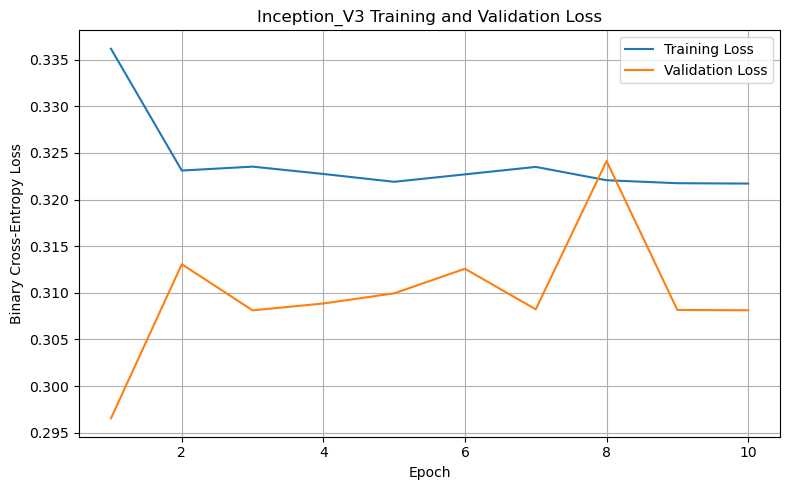

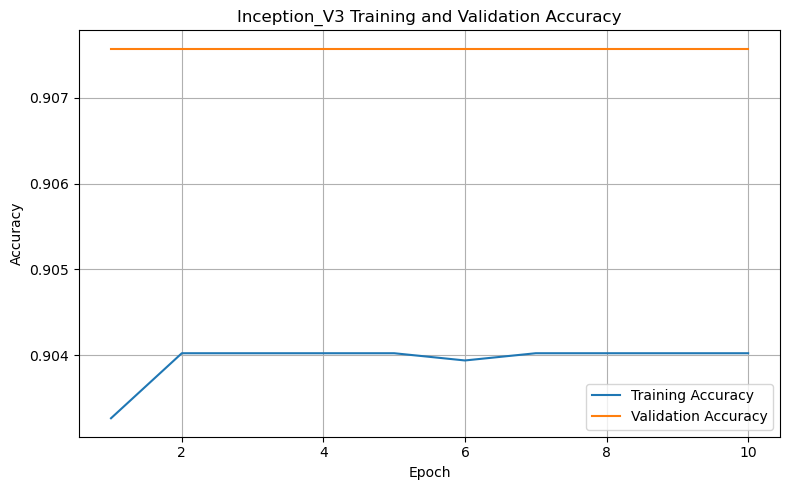

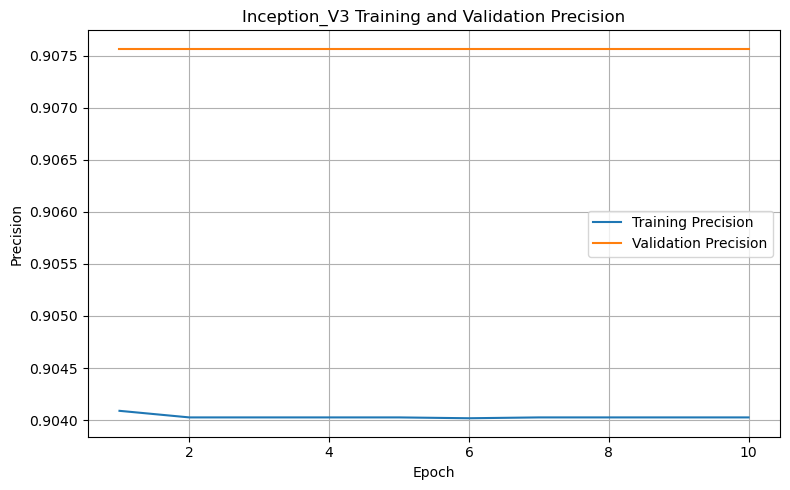

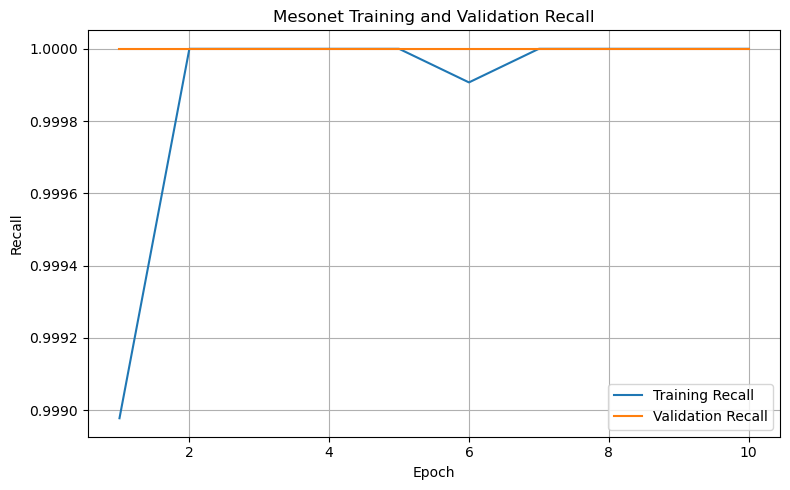

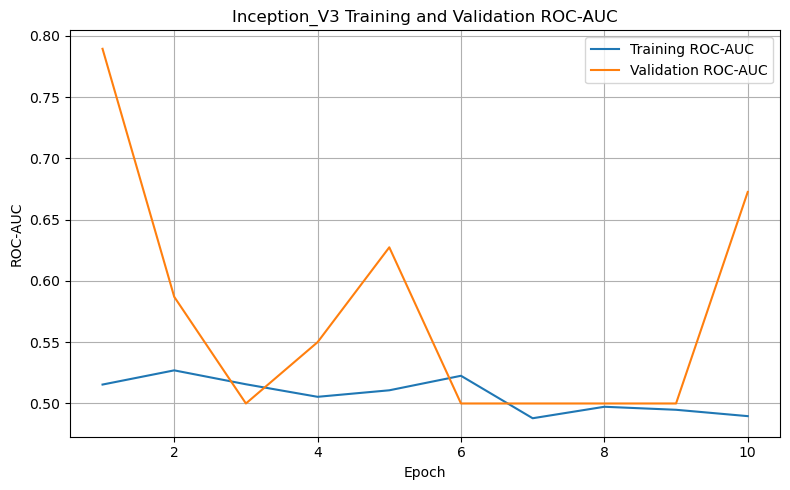

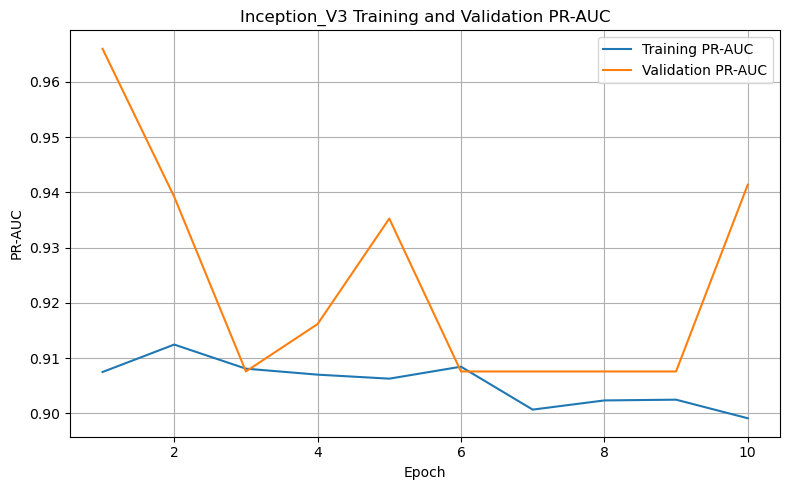

In [12]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Inception_V3 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Inception_V3 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Inception_V3 Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Inception_V3 Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Inception_V3 Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Inception_V3_celeb_10epochs.h5")


model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)



In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"Mesonet_160_celeb.h5")


In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_celeb),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_celeb[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_celeb,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_celeb)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_21320\3984712684.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 8.01 seconds, 1.3444 ms/image

Starting resource run 2/5
Run 2: 7.19 seconds, 1.2063 ms/image

Starting resource run 3/5
Run 3: 7.03 seconds, 1.1787 ms/image

Starting resource run 4/5
Run 4: 7.24 seconds, 1.2137 ms/image

Starting resource run 5/5
Run 5: 7.01 seconds, 1.1766 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,8.013756,1.344364,743.845957,3.192466,5.078125,6968.984375,7426.748609,7445.382812,457.764234,476.398438,...,7000.558594,7000.558594,0.0,0.0,80.424658,91,50.618562,80.700,0.112399,1
1,7.190541,1.206264,829.005773,3.245407,4.296875,6970.820312,7428.658440,7445.867188,457.838127,475.046875,...,7000.558594,7000.558594,0.0,0.0,85.969697,94,54.612788,72.573,0.108918,2
2,7.026528,1.178750,848.356448,3.190283,4.475000,6970.992188,7428.245667,7446.039062,457.253479,475.046875,...,7000.558594,7000.558594,0.0,0.0,86.937500,100,55.673641,71.664,0.107815,3
3,7.235134,1.213745,823.896327,3.074811,4.478125,6971.011719,7428.796520,7446.652344,457.784801,475.640625,...,7000.558594,7000.558594,0.0,0.0,87.151515,100,53.397394,69.481,0.105759,4
4,7.013572,1.176576,849.923560,3.181738,6.718750,6971.039062,7426.647400,7446.527344,455.608337,475.488281,...,7000.558594,7000.558594,0.0,0.0,86.750000,94,56.182016,72.733,0.109719,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Inception_V3 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Inception_V3 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,7.295906,0.413032,6.783059,7.808753
1,latency_ms_per_image,1.223940,0.069289,1.137906,1.309974
2,throughput_images_per_s,819.005613,43.561127,764.917330,873.093897
3,average_cpu_percent,3.176941,0.062370,3.099498,3.254384
4,peak_cpu_percent,5.009375,1.000266,3.767381,6.251369
5,average_ram_mb,7427.819327,1.044106,7426.522898,7429.115756
6,peak_ram_mb,7446.093750,0.514729,7445.454629,7446.732871
7,average_incremental_ram_mb,457.249796,0.947551,456.073256,458.426335
8,peak_incremental_ram_mb,475.524219,0.555611,474.834337,476.214101
9,average_gpu_memory_mb,7000.558594,0.000000,7000.558594,7000.558594



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 1.224 ± 0.069 (95% CI: 1.138–1.310)
peak_ram_mb: 7446.094 ± 0.515 (95% CI: 7445.455–7446.733)
peak_gpu_memory_mb: 7000.559 ± 0.000 (95% CI: 7000.559–7000.559)
average_gpu_utilization_percent: 85.447 ± 2.843 (95% CI: 81.917–88.976)
average_gpu_power_w: 54.097 ± 2.219 (95% CI: 51.342–56.852)


#genralization

In [14]:
#wild deepfake on celeb
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of Celeb-DF(V2) on wild deepfake dataset (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 23s 21ms/step - loss: 0.6813 - accuracy: 0.7500 - precision: 0.7500 - recall: 1.0000 - roc_auc: 0.4967 - pr_auc: 0.7481

Test results of Celeb-DF(V2) on wild deepfake dataset (Inception_V3):
loss: 0.6813
accuracy: 0.7500
precision: 0.7500
recall: 1.0000
roc_auc: 0.4967
pr_auc: 0.7481


In [16]:
#DFC on celeb
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of Celeb-DF(V2) on DFC dataset (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



188/188 [==============================] - 8s 35ms/step - loss: 1.2761 - accuracy: 0.5000 - precision: 0.5000 - recall: 1.0000 - roc_auc: 0.4823 - pr_auc: 0.4907

Test results of Celeb-DF(V2) on DFC dataset (Inception_V3):
loss: 1.2761
accuracy: 0.5000
precision: 0.5000
recall: 1.0000
roc_auc: 0.4823
pr_auc: 0.4907


In [18]:
#FF++ on celeb
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)
print("\nTest results of Celeb-DF(V2) on FF++ dataset (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



155/155 [==============================] - 3s 20ms/step - loss: 1.4724 - accuracy: 0.4166 - precision: 0.4166 - recall: 1.0000 - roc_auc: 0.6152 - pr_auc: 0.4880

Test results of Celeb-DF(V2) on FF++ dataset (Inception_V3):
loss: 1.4724
accuracy: 0.4166
precision: 0.4166
recall: 1.0000
roc_auc: 0.6152
pr_auc: 0.4880


# DFC

In [17]:
import h5py
import numpy as np
# Open the HDF5 file in read mode
with h5py.File('D://thesis//dataset//deepfake dataset//resized_images.h5', 'r') as h5f:
    # Access each dataset
    celeb = np.array(h5f['celeb'])
    ffhq = np.array(h5f['ffhq'])
    gdwct = np.array(h5f['gdwct'])
    attgan = np.array(h5f['attgan'])
    stargan = np.array(h5f['stargan'])
    stylegan2 = np.array(h5f['stylegan2'])
    stylegan = np.array(h5f['stylegan'])

# Now, 'celeb', 'ffhq', etc., are NumPy arrays containing your datasets
print(f"celeb shape: {celeb.shape}, dtype: {celeb.dtype}")
print(f"ffhq shape: {ffhq.shape}, dtype: {ffhq.dtype}")
print(f"ffhq shape: {gdwct.shape}, dtype: {gdwct.dtype}")
print(f"ffhq shape: {attgan.shape}, dtype: {attgan.dtype}")
print(f"ffhq shape: {stargan.shape}, dtype: {stargan.dtype}")
print(f"ffhq shape: {stylegan2.shape}, dtype: {stylegan2.dtype}")
print(f"ffhq shape: {stylegan.shape}, dtype: {stylegan.dtype}")
# Repeat for other datasets as needed
import cv2
# Function to resize images from (224, 224) to (160, 160)
def resize_images(image_array, target_size=(160, 160)):
    resized_images = np.array([cv2.resize(img, target_size) for img in image_array])
    return resized_images

celeb = resize_images(celeb, target_size=(160, 160))
ffhq = resize_images(ffhq, target_size=(160, 160))
gdwct = resize_images(gdwct, target_size=(160, 160))
attgan = resize_images(attgan, target_size=(160, 160))
stargan = resize_images(stargan, target_size=(160, 160))
stylegan = resize_images(stylegan, target_size=(160, 160))
stylegan2 = resize_images(stylegan2, target_size=(160, 160))
import random
# Randomly select 2500 distinct images
random_indices = random.sample(range(len(celeb)), 2500)  # Get 2500 random indices
celeb = celeb[random_indices]  # Select the random subse

import random
# Randomly select 2500 distinct images
random_indices = random.sample(range(len(ffhq)), 2500)  # Get 2500 random indices
ffhq = ffhq[random_indices]  # Select the random subse
print(f"celeb shape: {celeb.shape}, dtype: {celeb.dtype}")
print(f"ffhq shape: {ffhq.shape}, dtype: {ffhq.dtype}")
print(f"gdwct shape: {gdwct.shape}, dtype: {gdwct.dtype}")
print(f"attagan shape: {attgan.shape}, dtype: {attgan.dtype}")
print(f"stargan shape: {stargan.shape}, dtype: {stargan.dtype}")
print(f"stylegan2 shape: {stylegan2.shape}, dtype: {stylegan2.dtype}")
print(f"stylegan shape: {stylegan.shape}, dtype: {stylegan.dtype}")
import random
import numpy as np

def split_data(data, train_ratio=0.7):
    """
    Splits data into training and testing sets based on the specified ratio.

    Parameters:
        data (list or np.array): The dataset to split.
        train_ratio (float): The ratio of the data to include in the training set.

    Returns:
        tuple: Two datasets - train and test.
    """
    # Shuffle the data
    random.shuffle(data)

    # Calculate the split index
    split_index = int(len(data) * train_ratio)

    # Split the data
    train_data = data[:split_index]
    test_data = data[split_index:]

    return train_data, test_data

# Split `celeb` into 70% train and 30% test
celeb_train_hog, celeb_test_hog = split_data(celeb, train_ratio=0.7)

# Split `ffhq` into 70% train and 30% test
ffhq_train_hog, ffhq_test_hog = split_data(ffhq, train_ratio=0.7)

# Split `attgan` into 70% train and 30% test
attgan_train_hog, attgan_test_hog = split_data(attgan, train_ratio=0.7)

# Split `stargan` into 70% train and 30% test
stargan_train_hog, stargan_test_hog = split_data(stargan, train_ratio=0.7)

# Split `gdwct` into 70% train and 30% test
gdwct_train_hog, gdwct_test_hog = split_data(gdwct, train_ratio=0.7)

# Split `stylegan2` into 70% train and 30% test_hog
stylegan2_train_hog, stylegan2_test_hog = split_data(stylegan2, train_ratio=0.7)

# Split `stylegan` into 70% train and 30% test_hog
stylegan_train_hog, stylegan_test_hog = split_data(stylegan, train_ratio=0.7)

# Convert to NumPy arrays if needed
celeb_train_hog, celeb_test_hog = np.array(celeb_train_hog), np.array(celeb_test_hog)
ffhq_train_hog, ffhq_test_hog = np.array(ffhq_train_hog), np.array(ffhq_test_hog)
attgan_train_hog, attgan_test_hog = np.array(attgan_train_hog), np.array(attgan_test_hog)
stargan_train_hog, stargan_test_hog = np.array(stargan_train_hog), np.array(stargan_test_hog)
gdwct_train_hog, gdwct_test_hog = np.array(gdwct_train_hog), np.array(gdwct_test_hog)
stylegan2_train_hog, stylegan2_test_hog = np.array(stylegan2_train_hog), np.array(stylegan2_test_hog)
stylegan_train_hog, stylegan_test_hog = np.array(stylegan_train_hog), np.array(stylegan_test_hog)

# Print results for verification
print(f"celeb_train: {len(celeb_train_hog)} images, celeb_test: {len(celeb_test_hog)} images")
print(f"ffhq_train: {len(ffhq_train_hog)} images, ffhq_test: {len(ffhq_test_hog)} images")
print(f"attgan_train: {len(attgan_train_hog)} images, attgan_test: {len(attgan_test_hog)} images")
print(f"stargan_train: {len(stargan_train_hog)} images, stargan_test: {len(stargan_test_hog)} images")
print(f"gdwct_train: {len(gdwct_train_hog)} images, gdwct_test: {len(gdwct_test_hog)} images")
print(f"stylegan2_train: {len(stylegan2_train_hog)} images, stylegan2_test: {len(stylegan2_test_hog)} images")
print(f"stylegan_train: {len(stylegan_train_hog)} images, stylegan_test: {len(stylegan_test_hog)} images")

########################################################################################################################################
#######################################divide into 60,10 train and val
#########################################################################################################################################
def extract_validation(train_data):
    """
    Extract every 10th sample from the training data and store it in a validation set.

    Parameters:
        train_data (list or np.array): The training dataset.

    Returns:
        tuple: Updated training dataset and validation dataset.
    """
    # Select every 10th sample for the validation set
    validation_data = train_data[::10]

    # Remove the selected samples from the training dataset
    updated_train_data = [train_data[i] for i in range(len(train_data)) if i % 10 != 0]

    return np.array(updated_train_data), np.array(validation_data)


# Perform the operation for each dataset
celeb_train_hog, celeb_val_hog = extract_validation(celeb_train_hog)
ffhq_train_hog, ffhq_val_hog = extract_validation(ffhq_train_hog)
attgan_train_hog, attgan_val_hog = extract_validation(attgan_train_hog)
stargan_train_hog, stargan_val_hog = extract_validation(stargan_train_hog)
gdwct_train_hog, gdwct_val_hog = extract_validation(gdwct_train_hog)
stylegan2_train_hog, stylegan2_val_hog = extract_validation(stylegan2_train_hog)
stylegan_train_hog, stylegan_val_hog = extract_validation(stylegan_train_hog)

# Print results for verification
print(f"celeb_train: {len(celeb_train_hog)} images, celeb_val: {len(celeb_val_hog)} images")
print(f"ffhq_train: {len(ffhq_train_hog)} images, ffhq_val: {len(ffhq_val_hog)} images")
print(f"attgan_train: {len(attgan_train_hog)} images, attgan_val: {len(attgan_val_hog)} images")
print(f"stargan_train: {len(stargan_train_hog)} images, stargan_val: {len(stargan_val_hog)} images")
print(f"gdwct_train: {len(gdwct_train_hog)} images, gdwct_val: {len(gdwct_val_hog)} images")
print(f"stylegan2_train: {len(stylegan2_train_hog)} images, stylegan2_val: {len(stylegan2_val_hog)} images")
print(f"stylegan_train: {len(stylegan_train_hog)} images, stylegan_val: {len(stylegan_val_hog)} images")
############################################################################################################################################################
#################################################concatenate the labels 0,1 real and fake
#############################################################################################################################################################


celeb_train_labels = np.zeros(len(celeb_train_hog), dtype=int)
ffhq_train_labels = np.zeros(len(ffhq_train_hog), dtype=int)
atta_train_labels = np.ones(len(attgan_train_hog), dtype=int)
star_train_labels = np.ones(len(stargan_train_hog), dtype=int)
gdwct_train_labels = np.ones(len(gdwct_train_hog), dtype=int)
stylegan2_train_labels = np.ones(len(stylegan2_train_hog), dtype=int)
stylegan_train_labels = np.ones(len(stylegan_train_hog), dtype=int)

# Concatenate all training datasets into a single `train` variable
train_hog = np.concatenate([celeb_train_hog, ffhq_train_hog, attgan_train_hog, stargan_train_hog, gdwct_train_hog, stylegan2_train_hog, stylegan_train_hog], axis=0)
train_labels=np.concatenate([celeb_train_labels, ffhq_train_labels, atta_train_labels, star_train_labels, gdwct_train_labels, stylegan2_train_labels,
                              stylegan_train_labels], axis=0)




celeb_test_labels = np.zeros(len(celeb_test_hog), dtype=int)
ffhq_test_labels = np.zeros(len(ffhq_test_hog), dtype=int)
atta_test_labels = np.ones(len(attgan_test_hog), dtype=int)
star_test_labels = np.ones(len(stargan_test_hog), dtype=int)
gdwct_test_labels = np.ones(len(gdwct_test_hog), dtype=int)
stylegan2_test_labels = np.ones(len(stylegan2_test_hog), dtype=int)
stylegan_test_labels = np.ones(len(stylegan_test_hog), dtype=int)

# Concatenate all testing datasets into a single `test` variable
test_hog = np.concatenate([celeb_test_hog, ffhq_test_hog, attgan_test_hog, stargan_test_hog, gdwct_test_hog, stylegan2_test_hog, stylegan_test_hog], axis=0)
test_labels = np.concatenate([celeb_test_labels, ffhq_test_labels, atta_test_labels, star_test_labels, gdwct_test_labels, stylegan2_test_labels,
                        stylegan_test_labels], axis=0)




celeb_val_labels = np.zeros(len(celeb_val_hog), dtype=int)
ffhq_val_labels = np.zeros(len(ffhq_val_hog), dtype=int)
atta_val_labels = np.ones(len(attgan_val_hog), dtype=int)
star_val_labels = np.ones(len(stargan_val_hog), dtype=int)
gdwct_val_labels = np.ones(len(gdwct_val_hog), dtype=int)
stylegan2_val_labels = np.ones(len(stylegan2_val_hog), dtype=int)
stylegan_val_labels = np.ones(len(stylegan_val_hog), dtype=int)

# Concatenate all validation datasets into a single `val` variable
val_hog = np.concatenate([celeb_val_hog, ffhq_val_hog, attgan_val_hog, stargan_val_hog, gdwct_val_hog, stylegan2_val_hog, stylegan_val_hog], axis=0)
val_labels = np.concatenate([celeb_val_labels, ffhq_val_labels, atta_val_labels, star_val_labels, gdwct_val_labels, stylegan2_val_labels,
                       stylegan_val_labels], axis=0)

# Print the results for verification
print(f"Total train: {len(train_hog)} images")
print(f"Total test: {len(test_hog)} images")
print(f"Total val: {len(val_hog)} images")


# Print results for verification
print(f"Train Labels: {len(train_labels)} ")
print(f"Test Labels: {len(test_labels)} ")
print(f"Val Labels: {len(val_labels)} ")



celeb shape: (5000, 224, 224, 3), dtype: uint8
ffhq shape: (5000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
celeb shape: (2500, 160, 160, 3), dtype: uint8
ffhq shape: (2500, 160, 160, 3), dtype: uint8
gdwct shape: (1000, 160, 160, 3), dtype: uint8
attagan shape: (1000, 160, 160, 3), dtype: uint8
stargan shape: (1000, 160, 160, 3), dtype: uint8
stylegan2 shape: (1000, 160, 160, 3), dtype: uint8
stylegan shape: (1000, 160, 160, 3), dtype: uint8
celeb_train: 1750 images, celeb_test: 750 images
ffhq_train: 1750 images, ffhq_test: 750 images
attgan_train: 700 images, attgan_test: 300 images
stargan_train: 700 images, stargan_test: 300 images
gdwct_train: 700 images, gdwct_test: 300 images
stylegan2_train: 700 images, stylegan2_test: 300 images
stylegan_train: 700 images, stylegan

In [4]:

# Train model
history = model.fit(
    train_hog, train_labels,
    validation_data=(val_hog, val_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
394/394 [==============================] - 36s 72ms/step - loss: 0.4692 - accuracy: 0.7610 - precision: 0.7623 - recall: 0.7584 - roc_auc: 0.8558 - pr_auc: 0.8582 - val_loss: 0.1482 - val_accuracy: 0.9457 - val_precision: 0.9561 - val_recall: 0.9343 - val_roc_auc: 0.9849 - val_pr_auc: 0.9837
Epoch 2/10
394/394 [==============================] - 26s 67ms/step - loss: 0.1564 - accuracy: 0.9427 - precision: 0.9423 - recall: 0.9432 - roc_auc: 0.9843 - pr_auc: 0.9842 - val_loss: 0.8600 - val_accuracy: 0.7657 - val_precision: 0.6809 - val_recall: 1.0000 - val_roc_auc: 0.9427 - val_pr_auc: 0.8986
Epoch 3/10
394/394 [==============================] - 26s 65ms/step - loss: 0.0845 - accuracy: 0.9713 - precision: 0.9714 - recall: 0.9711 - roc_auc: 0.9948 - pr_auc: 0.9946 - val_loss: 0.0750 - val_accuracy: 0.9757 - val_precision: 0.9562 - val_recall: 0.9971 - val_roc_auc: 0.9956 - val_pr_auc: 0.9919
Epoch 4/10
394/394 [==============================] - 24s 60ms/step - loss: 0.0526 - acc

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [ ]:
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


818/188 [==============================] - 4s 20ms/step - loss: 0.2189 - accuracy: 0.9390 - precision: 0.9018 - recall: 0.9853 - roc_auc: 0.9927 - pr_auc: 0.9931

Test results:
loss: 0.2189
accuracy: 0.9390
precision: 0.9018
recall: 0.9853
roc_auc: 0.9927
pr_auc: 0.9931



In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_hog,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_hog,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Inception_V3 — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)


188/188 [==============================] - 3s 17ms/step

Inception_V3 — COMPLETE TEST-SET EVALUATION
Number of test samples:     3000
Decision threshold:         0.5000
Test loss:                  0.218863

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.939000 (93.90%)
Precision:                  0.901769 (90.18%)
Recall/Sensitivity:         0.985333 (98.53%)
F1-score:                   0.941701 (94.17%)
ROC-AUC:                    0.992704
PR-AUC:                     0.993104
Average Precision:          0.993106
EER:                        0.042000 (4.20%)
EER threshold:              0.975983

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.939000
Specificity:                0.892667
Matthews correlation:       0.881794
False-positive rate @ 0.5:  0.107333
False-negative rate @ 0.5:  0.014667

Confusion matrix
---------------

In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 14.0%
RAM Used: 274.0 MB
Time Usage: 6.0 s
GPU Memory Used: 1014.6 MB
Power Consumption: 93W


save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Inception_V3_dfc_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Inception_V3_160_dfc.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Inception_V3_dfc_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


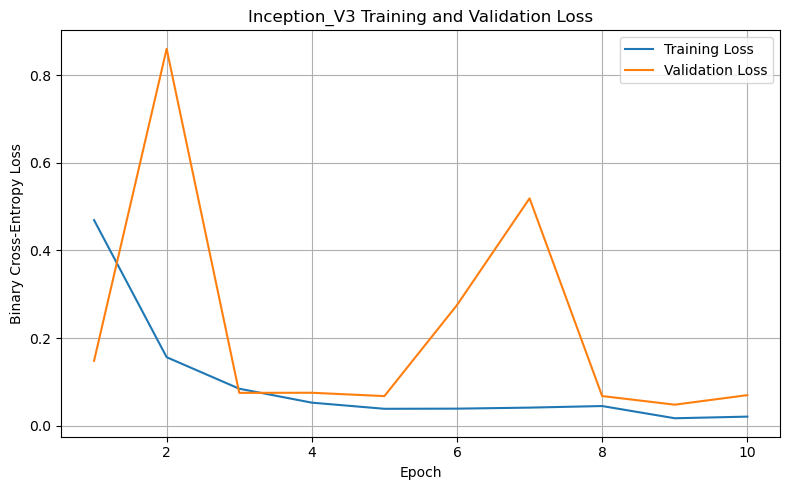

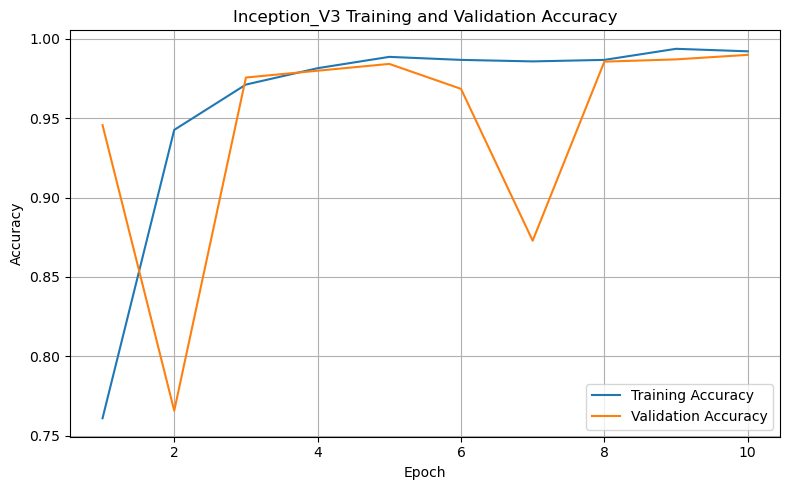

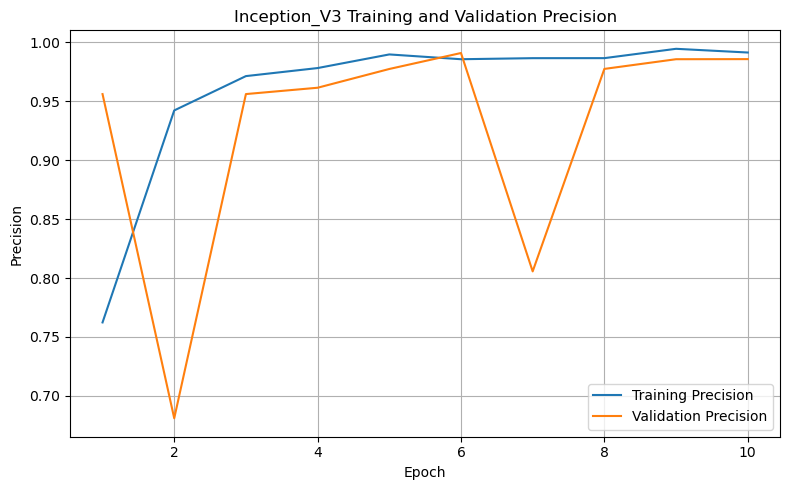

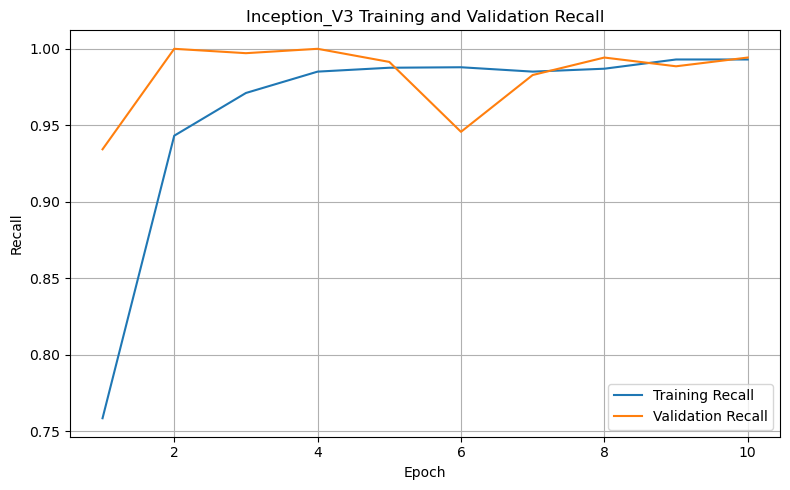

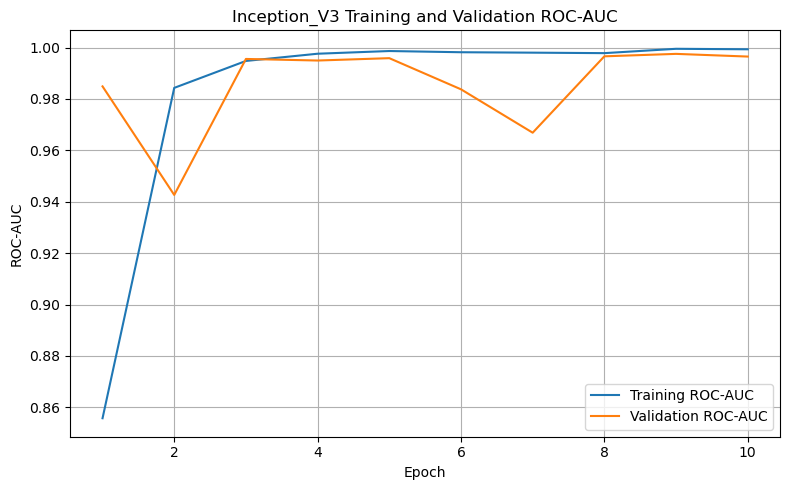

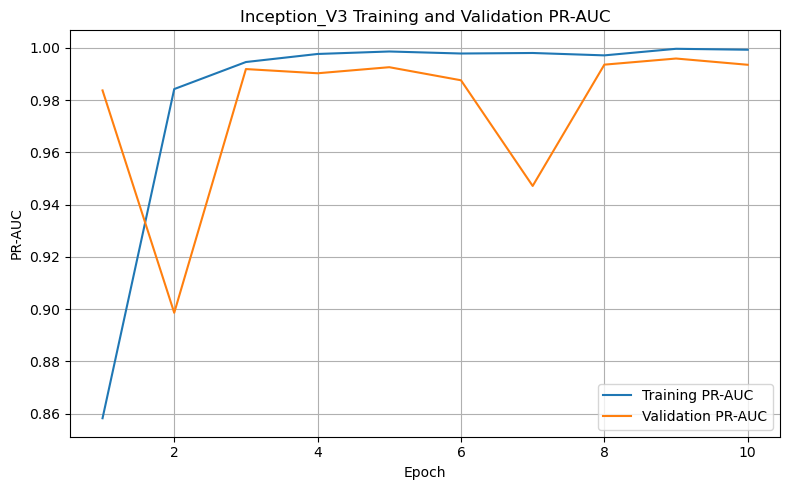

In [12]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Inception_V3 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Inception_V3 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Inception_V3 Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Inception_V3 Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Inception_V3 Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Inception_V3 Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Inception_V3_dfc_10epochs.h5")


model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)



In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"Inception_V3_160_dfc.h5")


In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_hog),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_hog[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_hog,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_hog)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_2368\3709879675.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 4.52 seconds, 1.5058 ms/image

Starting resource run 2/5
Run 2: 3.48 seconds, 1.1592 ms/image

Starting resource run 3/5
Run 3: 3.45 seconds, 1.1493 ms/image

Starting resource run 4/5
Run 4: 3.59 seconds, 1.1975 ms/image

Starting resource run 5/5
Run 5: 3.48 seconds, 1.1593 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,4.517354,1.505785,664.105624,3.075000,7.168750,6247.019531,6483.468114,6507.097656,236.448583,260.078125,...,7000.558594,7000.558594,0.0,0.0,66.651163,88,43.378233,66.874,0.055137,1
1,3.477557,1.159186,862.674598,3.010511,4.478125,6249.074219,6483.888613,6507.238281,234.814394,258.164062,...,7000.558594,7000.558594,0.0,0.0,81.303030,87,50.243667,74.936,0.048329,2
2,3.447972,1.149324,870.076747,2.973828,4.031250,6249.160156,6484.272827,6508.488281,235.112671,259.328125,...,7000.558594,7000.558594,0.0,0.0,81.781250,90,50.778125,72.364,0.048595,3
3,3.592540,1.197513,835.063841,3.073254,4.928125,6249.179688,6484.595358,6507.320312,235.415671,258.140625,...,7000.558594,7000.558594,0.0,0.0,81.529412,90,48.577118,72.853,0.048247,4
4,3.477938,1.159313,862.580069,3.077841,4.296875,6249.187500,6486.222064,6507.339844,237.034564,258.152344,...,7000.558594,7000.558594,0.0,0.0,80.363636,88,50.958758,83.543,0.049080,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Inception_V3 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Inception_V3 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,3.702672,0.458773,3.133030,4.272314
1,latency_ms_per_image,1.234224,0.152924,1.044343,1.424105
2,throughput_images_per_s,818.900176,87.558254,710.182243,927.618108
3,average_cpu_percent,3.042087,0.047406,2.983225,3.100949
4,peak_cpu_percent,4.980625,1.266094,3.408561,6.552689
5,average_ram_mb,6484.489395,1.056436,6483.177657,6485.801134
6,peak_ram_mb,6507.496875,0.562353,6506.798621,6508.195129
7,average_incremental_ram_mb,235.765177,0.939454,234.598690,236.931663
8,peak_incremental_ram_mb,258.772656,0.889864,257.667744,259.877568
9,average_gpu_memory_mb,7000.558594,0.000000,7000.558594,7000.558594



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 1.234 ± 0.153 (95% CI: 1.044–1.424)
peak_ram_mb: 6507.497 ± 0.562 (95% CI: 6506.799–6508.195)
peak_gpu_memory_mb: 7000.559 ± 0.000 (95% CI: 7000.559–7000.559)
average_gpu_utilization_percent: 78.326 ± 6.548 (95% CI: 70.195–86.456)
average_gpu_power_w: 48.787 ± 3.166 (95% CI: 44.856–52.719)


#genralization

In [14]:
#wild deepfake on dfc
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of DFC on wild deepfake dataset (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 23s 20ms/step - loss: 2.6255 - accuracy: 0.3682 - precision: 0.7576 - recall: 0.2317 - roc_auc: 0.5281 - pr_auc: 0.7526

Test results of DFC on wild deepfake dataset (Inception_V3):
loss: 2.6255
accuracy: 0.3682
precision: 0.7576
recall: 0.2317
roc_auc: 0.5281
pr_auc: 0.7526


In [16]:
#celeb on dfc
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of DFC on Celeb-DF(V2) dataset (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



373/373 [==============================] - 9s 21ms/step - loss: 1.4539 - accuracy: 0.8777 - precision: 0.9054 - recall: 0.9657 - roc_auc: 0.5033 - pr_auc: 0.9047

Test results of DFC on Celeb-DF(V2) dataset (Inception_V3):
loss: 1.4539
accuracy: 0.8777
precision: 0.9054
recall: 0.9657
roc_auc: 0.5033
pr_auc: 0.9047


In [18]:
#FF++ on hog
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)
print("\nTest results of dfc on FF++ dataset (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



155/155 [==============================] - 3s 22ms/step - loss: 7.9169 - accuracy: 0.4453 - precision: 0.4212 - recall: 0.8865 - roc_auc: 0.5099 - pr_auc: 0.4222

Test results of dfc on FF++ dataset (Inception_V3):
loss: 7.9169
accuracy: 0.4453
precision: 0.4212
recall: 0.8865
roc_auc: 0.5099
pr_auc: 0.4222


# FF++

LOAD THE DATASET

In [3]:
import os, cv2, numpy as np

FINAL_ROOT = r'D:\thesis\ff_final'

def load_split(split, cls):
    base = os.path.join(FINAL_ROOT, split, cls)
    nested, ids = [], []
    for vid_id in sorted(os.listdir(base)):
        d = os.path.join(base, vid_id)
        frames = [cv2.imread(os.path.join(d, f)) for f in sorted(os.listdir(d))]
        if frames:
            nested.append(frames); ids.append(vid_id)
    return nested, ids

# Main splits
ff_real_train_f, ff_real_train_ids = load_split('train', 'real')
ff_fake_train_f, ff_fake_train_ids = load_split('train', 'fake')
ff_real_val_f,   ff_real_val_ids   = load_split('val',   'real')
ff_fake_val_f,   ff_fake_val_ids   = load_split('val',   'fake')
ff_real_test_f,  ff_real_test_ids  = load_split('test',  'real')
ff_fake_test_f,  ff_fake_test_ids  = load_split('test',  'fake')

print("Reloaded main splits. Example shape:", np.shape(ff_real_train_f[0][0]))  # (160,160,3)
print("Real train videos:", len(ff_real_train_f), "| Fake train videos:", len(ff_fake_train_f))
import numpy as np


def combine_split(real_videos, fake_videos):
    """
    Combine all frames from the real and fake video groups.

    Labels:
        0 = Real
        1 = Fake
    """

    real_frames = [
        frame
        for video in real_videos
        for frame in video
        if frame is not None
    ]

    fake_frames = [
        frame
        for video in fake_videos
        for frame in video
        if frame is not None
    ]

    if not real_frames:
        raise ValueError("No real frames found.")

    if not fake_frames:
        raise ValueError("No fake frames found.")

    real_frames = np.stack(real_frames).astype(np.uint8)
    fake_frames = np.stack(fake_frames).astype(np.uint8)

    images = np.concatenate(
        [real_frames, fake_frames],
        axis=0
    )

    real_labels = np.zeros(
        len(real_frames),
        dtype=np.uint8
    )

    fake_labels = np.ones(
        len(fake_frames),
        dtype=np.uint8
    )

    labels = np.concatenate(
        [real_labels, fake_labels],
        axis=0
    )

    return images, labels
# Training data
train_ff, train_ff_labels = combine_split(
    ff_real_train_f,
    ff_fake_train_f
)

# Validation data
val_ff, val_ff_labels = combine_split(
    ff_real_val_f,
    ff_fake_val_f
)

# Testing data
test_ff, test_ff_labels = combine_split(
    ff_real_test_f,
    ff_fake_test_f
)
print("\nTRAIN")
print("Images:", train_ff.shape)
print("Labels:", train_ff_labels.shape)
print("Real:", np.sum(train_ff_labels == 0))
print("Fake:", np.sum(train_ff_labels == 1))

print("\nVALIDATION")
print("Images:", val_ff.shape)
print("Labels:", val_ff_labels.shape)
print("Real:", np.sum(val_ff_labels == 0))
print("Fake:", np.sum(val_ff_labels == 1))

print("\nTEST")
print("Images:", test_ff.shape)
print("Labels:", test_ff_labels.shape)
print("Real:", np.sum(test_ff_labels == 0))
print("Fake:", np.sum(test_ff_labels == 1))

print("\nData types")
print("Train images:", train_ff.dtype)
print("Train labels:", train_ff_labels.dtype)

Reloaded main splits. Example shape: (160, 160, 3)
Real train videos: 517 | Fake train videos: 320

TRAIN
Images: (4595, 160, 160, 3)
Labels: (4595,)
Real: 2948
Fake: 1647

VALIDATION
Images: (948, 160, 160, 3)
Labels: (948,)
Real: 499
Fake: 449

TEST
Images: (2475, 160, 160, 3)
Labels: (2475,)
Real: 1444
Fake: 1031

Data types
Train images: uint8
Train labels: uint8


In [4]:

# Train model
history = model.fit(
    train_ff, train_ff_labels,
    validation_data=(val_ff, val_ff_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
288/288 [==============================] - 29s 74ms/step - loss: 0.6463 - accuracy: 0.6437 - precision: 0.5060 - recall: 0.2556 - roc_auc: 0.6205 - pr_auc: 0.4650 - val_loss: 0.7510 - val_accuracy: 0.5264 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.7165 - val_pr_auc: 0.6543
Epoch 2/10
288/288 [==============================] - 20s 70ms/step - loss: 0.5808 - accuracy: 0.7077 - precision: 0.6437 - recall: 0.4135 - roc_auc: 0.7355 - pr_auc: 0.6066 - val_loss: 0.6638 - val_accuracy: 0.5823 - val_precision: 0.9344 - val_recall: 0.1269 - val_roc_auc: 0.8060 - val_pr_auc: 0.7934
Epoch 3/10
288/288 [==============================] - 20s 68ms/step - loss: 0.3835 - accuracy: 0.8305 - precision: 0.7969 - recall: 0.7073 - roc_auc: 0.8980 - pr_auc: 0.8474 - val_loss: 0.4336 - val_accuracy: 0.7996 - val_precision: 0.9642 - val_recall: 0.5991 - val_roc_auc: 0.9367 - val_pr_auc: 0.9396
Epoch 4/10
288/288 [==============================] - 19s 67ms/step - loss: 0.28

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_ff,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_ff_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Inception_V3 — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)


155/155 [==============================] - 3s 17ms/step

Inception_V3 — COMPLETE TEST-SET EVALUATION
Number of test samples:     2475
Decision threshold:         0.5000
Test loss:                  0.738171

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.785859 (78.59%)
Precision:                  0.765079 (76.51%)
Recall/Sensitivity:         0.701261 (70.13%)
F1-score:                   0.731781 (73.18%)
ROC-AUC:                    0.873676
PR-AUC:                     0.806882
Average Precision:          0.807053
EER:                        0.209808 (20.98%)
EER threshold:              0.124272

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.773761
Specificity:                0.846260
Matthews correlation:       0.555587
False-positive rate @ 0.5:  0.153740
False-negative rate @ 0.5:  0.298739

Confusion matrix
--------------

In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 18.0%
RAM Used: 228.3 MB
Time Usage: 5.4 s
GPU Memory Used: 859.5 MB
Power Consumption: 93W


#save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Inception_V3_ff_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Inception_V3_160_ff.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Inception_V3_ff_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


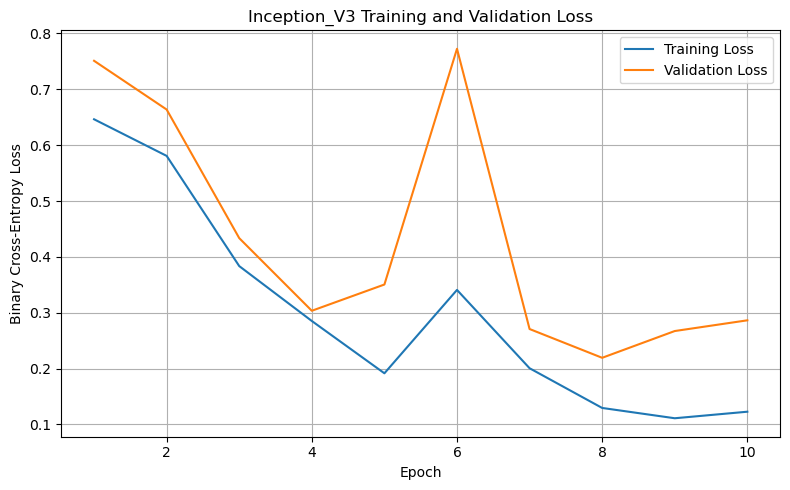

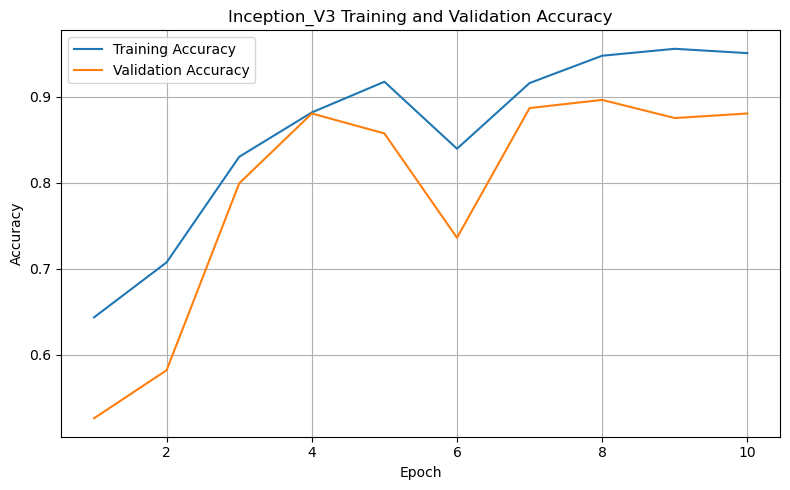

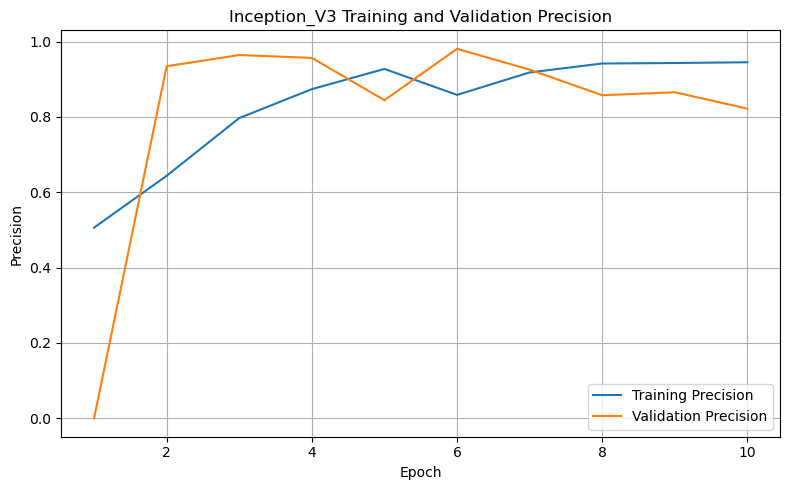

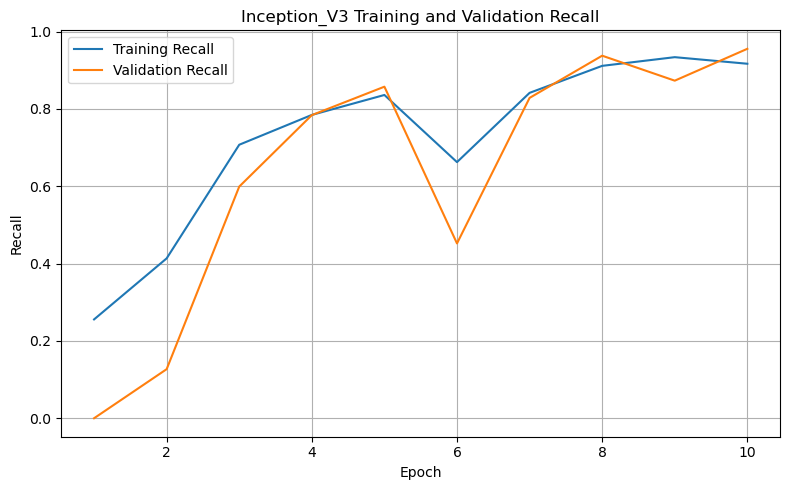

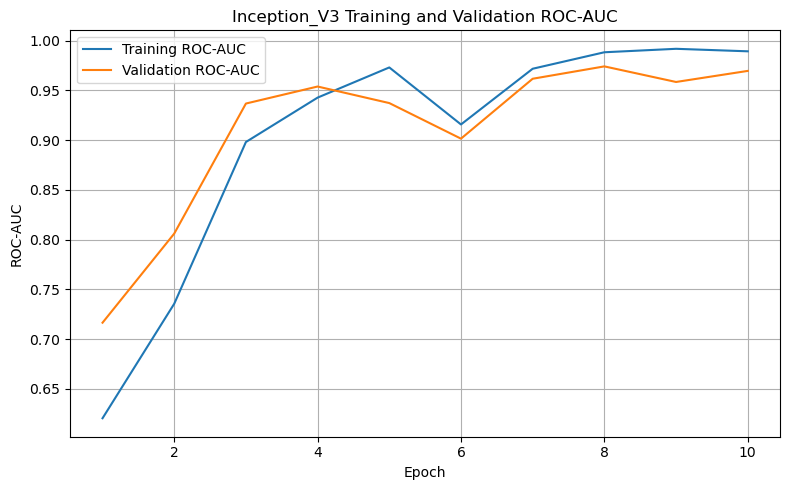

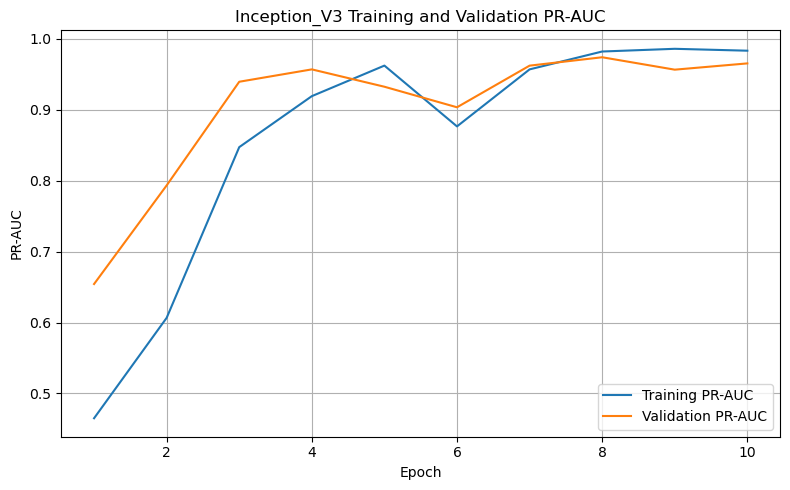

In [12]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Inception_V3 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Inception_V3 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Inception_V3 Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Inception_V3 Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Inception_V3 Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Inception_V3 Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Inception_V3_ff_10epochs.h5")


model = tf.keras.models.load_model(MODEL_PATH,compile=False)

In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_ff),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_ff[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_ff,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_ff)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_22848\115312294.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 3.49 seconds, 1.4102 ms/image

Starting resource run 2/5
Run 2: 2.78 seconds, 1.1243 ms/image

Starting resource run 3/5
Run 3: 2.90 seconds, 1.1700 ms/image

Starting resource run 4/5
Run 4: 2.86 seconds, 1.1551 ms/image

Starting resource run 5/5
Run 5: 2.84 seconds, 1.1455 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,3.490189,1.410177,709.130652,2.974527,4.437500,5227.214844,5423.078598,5448.406250,195.863755,221.191406,...,7000.558594,7000.558594,0.0,0.0,65.575758,94,47.163424,94.709,0.045814,1
1,2.782636,1.124298,889.444238,3.014931,3.993750,5229.277344,5425.857784,5449.042969,196.580440,219.765625,...,7000.558594,7000.558594,0.0,0.0,80.111111,88,49.199926,92.838,0.037818,2
2,2.895703,1.169981,854.714786,3.083929,6.659375,5229.410156,5425.701869,5449.105469,196.291713,219.695312,...,7000.558594,7000.558594,0.0,0.0,78.357143,91,47.870071,71.979,0.038275,3
3,2.858777,1.155061,865.754771,2.959152,5.328125,5229.425781,5424.922573,5449.125000,195.496791,219.699219,...,7000.558594,7000.558594,0.0,0.0,77.857143,94,48.314179,72.006,0.038958,4
4,2.835089,1.145491,872.988467,2.983102,4.928125,5229.441406,5426.271412,5449.179688,196.830006,219.738281,...,7000.558594,7000.558594,0.0,0.0,79.703704,93,47.373481,71.684,0.037431,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Inception_V3 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Inception_V3 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,2.972479,0.292302,2.609538,3.335420
1,latency_ms_per_image,1.201002,0.118102,1.054359,1.347644
2,throughput_images_per_s,838.406583,73.360235,747.317820,929.495345
3,average_cpu_percent,3.003128,0.049551,2.941603,3.064653
4,peak_cpu_percent,5.069375,1.021180,3.801412,6.337338
5,average_ram_mb,5425.166447,1.265322,5423.595343,5426.737552
6,peak_ram_mb,5448.971875,0.319948,5448.574607,5449.369143
7,average_incremental_ram_mb,196.212541,0.537780,195.544799,196.880283
8,peak_incremental_ram_mb,220.017969,0.656614,219.202675,220.833262
9,average_gpu_memory_mb,7000.558594,0.000000,7000.558594,7000.558594



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 1.201 ± 0.118 (95% CI: 1.054–1.348)
peak_ram_mb: 5448.972 ± 0.320 (95% CI: 5448.575–5449.369)
peak_gpu_memory_mb: 7000.559 ± 0.000 (95% CI: 7000.559–7000.559)
average_gpu_utilization_percent: 76.321 ± 6.078 (95% CI: 68.774–83.868)
average_gpu_power_w: 47.984 ± 0.813 (95% CI: 46.974–48.994)


#gernalization

In [14]:
#wild deepfake on ff
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on wild deepfake dataset (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 24s 21ms/step - loss: 2.5008 - accuracy: 0.3544 - precision: 0.7082 - recall: 0.2367 - roc_auc: 0.4784 - pr_auc: 0.7205

Test results of FF++ on wild deepfake dataset (Inception_V3):
loss: 2.5008
accuracy: 0.3544
precision: 0.7082
recall: 0.2367
roc_auc: 0.4784
pr_auc: 0.7205


In [16]:
#celeb on ff
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on Celeb-df(v2) dataset (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 8s 22ms/step - loss: 2.3538 - accuracy: 0.3218 - precision: 0.9849 - recall: 0.2538 - roc_auc: 0.7416 - pr_auc: 0.9633

Test results of FF++ on Celeb-df(v2) dataset (Inception_V3):
loss: 2.3538
accuracy: 0.3218
precision: 0.9849
recall: 0.2538
roc_auc: 0.7416
pr_auc: 0.9633


In [18]:
#DFC on ff
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on DFC dataset (Inception_V3):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


188/188 [==============================] - 10s 48ms/step - loss: 1.9968 - accuracy: 0.4240 - precision: 0.4520 - recall: 0.7160 - roc_auc: 0.3363 - pr_auc: 0.3948

Test results of FF++ on DFC dataset (Inception_V3):
loss: 1.9968
accuracy: 0.4240
precision: 0.4520
recall: 0.7160
roc_auc: 0.3363
pr_auc: 0.3948
